<a href="https://colab.research.google.com/github/JacobeJonathan/ML/blob/main/ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Visualización de la Nueva Flor en el Gráfico de Dispersión

Ahora, para entender mejor dónde se ubica la nueva flor en relación con las especies conocidas, podemos graficarla junto con el conjunto de datos original.

### Visualización de la Nueva Flor en el Gráfico de Dispersión

Ahora, para entender mejor dónde se ubica la nueva flor en relación con las especies conocidas, podemos graficarla junto con el conjunto de datos original.

In [29]:
pip install numpy scipy scikit-learn matplotlib pandas pillow graphviz

In [30]:
pip install nltk spacy

##### Utilizando numpy

In [31]:
import numpy as np

In [32]:
x = np.array([[1,2,3],[4,5,6]])

In [33]:
print(x)

[[1 2 3]
 [4 5 6]]


##### Utilizando scipy

In [34]:
from scipy import sparse

In [35]:
eye = np.eye(4)
print(eye)

[[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]


In [36]:
sparse_matrix = sparse.csr_matrix(eye)

In [37]:
print(sparse_matrix)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 4 stored elements and shape (4, 4)>
  Coords	Values
  (0, 0)	1.0
  (1, 1)	1.0
  (2, 2)	1.0
  (3, 3)	1.0


In [38]:
data = np.ones(4)
row_indices = np.arange(4)
col_indices = np.arange(4)
eye_coo = sparse.coo_matrix((data, (row_indices, col_indices)))

In [39]:
print(eye_coo)

<COOrdinate sparse matrix of dtype 'float64'
	with 4 stored elements and shape (4, 4)>
  Coords	Values
  (0, 0)	1.0
  (1, 1)	1.0
  (2, 2)	1.0
  (3, 3)	1.0


##### Utilizando matplotlib

In [40]:
import matplotlib.pyplot as plt

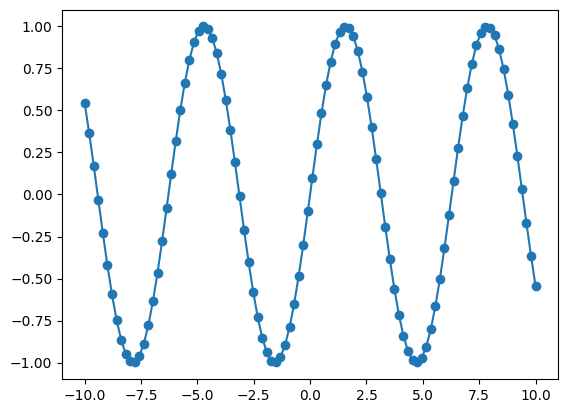

In [41]:
# Generate a sequence of numbers from -10 to 10 with 100 steps in between
x = np.linspace(-10, 10, 100)
# Create a second array using sine
y = np.sin(x)
# The plot function makes a line chart of one array against another
plt.plot(x, y, marker="o")

#### Pandas -> Trabaja con dataframes

In [42]:
import pandas as pd

In [43]:
##create a simple dataset of people
data = {'Name': ["John", "Anna", "Peter", "Linda"],
        'Location' : ["New York", "Paris", "Berlin", "London"],
        'Age' : [24, 13, 53, 33]
       }

In [44]:
data_pandas = pd.DataFrame(data)
display(data_pandas)

,Name,Location,Age
0,John,New York,24
1,Anna,Paris,13
2,Peter,Berlin,53
3,Linda,London,33


In [45]:
display(data_pandas[data_pandas.Location =="New York"])

,Name,Location,Age
0,John,New York,24


In [46]:
display(data_pandas[data_pandas.Age > 30])

,Name,Location,Age
2,Peter,Berlin,53
3,Linda,London,33


## Librerias que siempre utilizaremos:
- import numpy as np
- import matplotlib.pyplot as plt
- import pandas as pd
- import mglearn
- from IPython.display import display

In [47]:
##### EXERCISE 1 - Classifying Iris Species

In [48]:
import pandas as pd
from sklearn.datasets import load_iris

# Load the Iris dataset
iris = load_iris()

# Create a DataFrame using the data and feature names
iris_dataset = pd.DataFrame(data=iris.data, columns=iris.feature_names)

In [49]:
display(iris_dataset.head(5))

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [50]:
print(iris.DESCR[:193] + "\n...")
print("Target names: {}".format(iris.target_names))

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive 
...
Target names: ['setosa' 'versicolor' 'virginica']


A partir de estos datos, podemos observar que las primeras cinco flores tienen una anchura de pétalo de 0.2 cm y que la primera flor tiene el sépalo más largo, con 5.1 cm.

In [51]:
print("Type of target: {}".format(type(iris.target)))

Type of target: <class 'numpy.ndarray'>


In [52]:
print("Shape of target: {}".format(iris.target.shape))

Shape of target: (150,)


In [53]:
print("Target:\n{}".format(iris.target))

Target:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


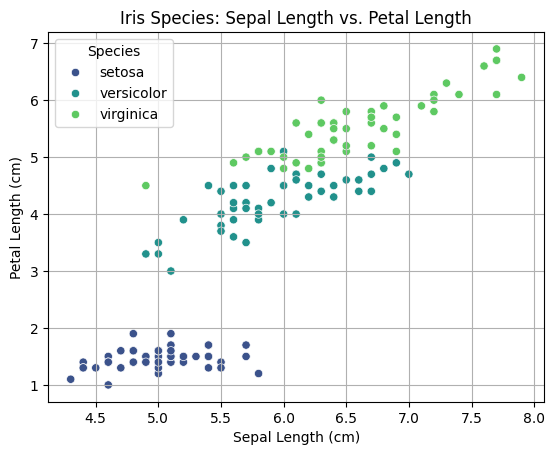

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a scatter plot of sepal length vs petal length, colored by species
sns.scatterplot(
    x='sepal length (cm)',
    y='petal length (cm)',
    hue=iris.target_names[iris.target],
    data=iris_dataset,
    palette='viridis'
)
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Petal Length (cm)')
plt.title('Iris Species: Sepal Length vs. Petal Length')
plt.legend(title='Species')
plt.grid(True)
plt.show()

### Preparación de los datos para el Modelo

Antes de construir el modelo, debemos dividir nuestros datos en un conjunto de entrenamiento y un conjunto de prueba. El conjunto de entrenamiento se utilizará para que el modelo 'aprenda' los patrones, y el conjunto de prueba para evaluar qué tan bien generaliza el modelo a datos nuevos e invisibles.

In [55]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(iris_dataset, iris.target, random_state=0)

print("Forma de X_train: {}".format(X_train.shape))
print("Forma de y_train: {}".format(y_train.shape))
print("Forma de X_test: {}".format(X_test.shape))
print("Forma de y_test: {}".format(y_test.shape))

Forma de X_train: (112, 4)
Forma de y_train: (112,)
Forma de X_test: (38, 4)
Forma de y_test: (38,)


In [56]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=1)

# Entrenar el modelo con los datos de entrenamiento
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=1)

### Haciendo una Predicción con Nueva Data

Ahora, podemos simular que tenemos una nueva flor con ciertas medidas y usar nuestro modelo entrenado para predecir a qué especie pertenece.

El modelo espera 4 valores: `sepal length (cm)`, `sepal width (cm)`, `petal length (cm)`, `petal width (cm)`. Asegúrate de que los valores que introduces estén en el mismo orden y en las mismas unidades (centímetros).

In [65]:
import numpy as np

print("Por favor, introduce las medidas de la nueva flor (en cm):")
sepal_length = float(input("Longitud del sépalo: "))
sepal_width = float(input("Ancho del sépalo: "))
petal_length = float(input("Longitud del pétalo: "))
petal_width = float(input("Ancho del pétalo: "))

# Crea un array NumPy con las nuevas medidas
x_new = np.array([[sepal_length, sepal_width, petal_length, petal_width]])
print("Forma de x_new: {}".format(x_new.shape))

# Realiza la predicción
prediction = knn.predict(x_new)

print("Predicción del tipo de flor: {}".format(prediction))
print("Nombre de la especie predicha: {}".format(iris.target_names[prediction][0]))

Por favor, introduce las medidas de la nueva flor (en cm):
Longitud del sépalo: 5
Ancho del sépalo: 6
Longitud del pétalo: 4
Ancho del pétalo: 5
Forma de x_new: (1, 4)
Predicción del tipo de flor: [2]
Nombre de la especie predicha: virginica


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


### Visualización de la Nueva Flor en el Gráfico de Dispersión

Ahora, para entender mejor dónde se ubica la nueva flor en relación con las especies conocidas, podemos graficarla junto con el conjunto de datos original.

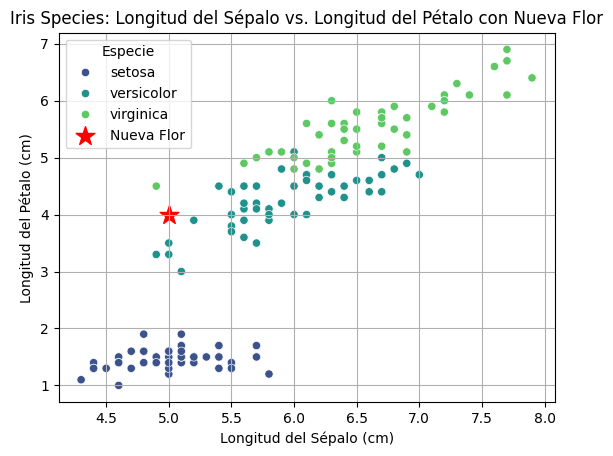

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns

# Recrear el scatter plot original con las especies
sns.scatterplot(
    x='sepal length (cm)',
    y='petal length (cm)',
    hue=iris.target_names[iris.target],
    data=iris_dataset,
    palette='viridis'
    # Se eliminó el argumento 'label' ya que seaborn lo maneja automáticamente con 'hue'
)

# Añadir el punto de la nueva flor al gráfico
plt.scatter(
    x_new[0, 0], # Sepal length de la nueva flor
    x_new[0, 2], # Petal length de la nueva flor
    s=200,       # Tamaño del punto
    marker='*',  # Forma del punto
    color='red', # Color del punto
    label='Nueva Flor' # Esta etiqueta se usa para la leyenda de la nueva flor
)

plt.xlabel('Longitud del Sépalo (cm)')
plt.ylabel('Longitud del Pétalo (cm)')
plt.title('Iris Species: Longitud del Sépalo vs. Longitud del Pétalo con Nueva Flor')
plt.legend(title='Especie') # Se llama a legend después de ambos plots para incluir ambas leyendas
plt.grid(True)
plt.show()

Los significados de los números vienen dados por el array `iris.target_names`:

*   `0` significa **setosa**
*   `1` significa **versicolor**
*   `2` significa **virginica**